<img src="https://raw.githubusercontent.com/AllenSWDB/allenswdb.github.io/main/databook/resources/swdb_logo_new.jpg">  

# Simulated Analysis: Behavioral Correlates in Neural Recordings


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; color: #000000;">

## Motivation

The purpose of this exercise is to illustrate how simulations can be used to validate a data analysis 
*workflow* prior to looking at the data, or even prior to collecting the data. As a toy example we'll work 
up code to test a hypothesis in a dataset such as the 
[visual behavior ophys dataset](https://allenswdb.github.io/physiology/ophys/visual-behavior/VB-Ophys.html). 

Suppose we hypothesize the existence of a distributed network of cells (neurons) in the brain responsible for 
the cognitive state of being "on task" or "in the zone", such that the animal's task performance is higher when 
this group of neurons is more active. To look for such neurons, we plan to record from a large population of 
individual cells while an animal performs a task, and then search for cells whose activity is correlated with 
the animal's **behavioral performance** (for example, its accuracy on a change detection task). 

We have an idea for the workflow, following a pattern used in many published studies:

* Screen the population for any cells whose activity significantly correlates with behavioral 
performance.
* If any are found, define this group of cells as the population of interest, and summarize the time-varying 
activity of this population by averaging the activity of the cells.
* Test how well this aggregate population activity correlates with performance.

Before touching data we can simulate fake data and use it 
to develop and validate the proposed analysis workflow. The value of this is threefold: first, it is vastly easier 
to simulate data than to collect or extract it, so this is by far the easiest way to validate (or invalidate) a 
proposed analyis. Second, when we simulate data it forces us to be explicit about all our assumptions. 
But most importantly, when 
we simulate data we have access to the **ground truth** about whether the hypothesized effect is present or absent, 
and if present, exactly which cells participate, how strong the effect is, and so on. Therefore we can compare the 
output of our proposed analysis workflow to what we know to be the true answer -- a luxury we never have when 
we turn to real data.

## Roadmap of this workshop
- **Part 1 (this notebook): implement analysis on simulated random data** Simulate data with no real effect and analyze it by our proposed workflow
-  **Part 2 (next notebok): refine the analysis**: Explore ways of overcoming any pitfalls of the analysis we discovered in Part 1
- **Part 3 (time permitting): simulate ground truth of a real effect** Apply our refined analysis workflow(s) to fake data in which we simulate a genuine effect.

There are three follow-up extension notebooks you can explore on your own:

-  **Extension 1: Power calculations.** Building on Part 3, sweep effect size and sample size 
systematically to see how much data we would need for each alternative analysis method we 
came up with so far.
-  **Extension 2: Try it on real data.** Building on Part 2, a scaffold to get you started on 
loading real data so you can check if the assumptions of your analysis are true, or try running
any validated analysis pipeline(s) on real data.
- **Extension 3: Further refinements.** Additional explorations and further refinements to illustrate
and address remaining limitations of the analysis after the refinement ideas in Part 2.

</div>



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; color: #000000;">

#### Implementation note

We rely entirely on `numpy` random number distribution and `scipy.stats` statistical functions:

- `scipy.stats.pearsonr` for the per-cell correlation with performance (one cell at a time in
  the single-run analyses, or with `axis=0` in the heavier repeated simulations),
- `scipy.stats.linregress` for the best-fit line in the scatter plots

</div>



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; color: #000000;">

# Step 1: Simulate Data with No Real Effect

Behavioral performance is not defined for a single trial. Therefore we will need to split each
session into short groups of trials. A good compromise between estimation accuracy and temporal
 resolution might be `Ntrials = 20` trials per group.

We could have simulated cell activity and trial outcome for each trial, but since we know we will be
analyzing the data in blocks of trials, we will skip ahead and just simulate the random values for
each group of trials.  We will assume a typical session contains about 400 trials, 
so `Ngroups = 20` groups of trials.

</div>



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; color: #000000;">

## Simulating behavior 

For each trial group we will measure the animal's behavioral performance on the 
task, giving a performance score $P$ (e.g. percent correct). To simulate the assumption
that performance fluctuates over a session, we can draw a
score for each trial group at random from a normal distribution with mean $\mu_P = 75$ and
standard deviation $\sigma_P = 8$.  

*Notice that this implies a specific model for exactly how performance fluctuates*

</div>



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; color: #000000;">

#### Implementation note
If our simulations were truly random, we would all see different results each time we run this code, potentially causing confusion (and issues with version control). 
Instead, we use a pseudo-random number generator (in numpy) and fix a "seed" so the results will be reproducible.

</div>


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Set a seed so the notebook is reproducible (remove for fresh random draws)
rng = np.random.default_rng(0)

In [2]:
Ngroups = 20
mean_perf, sd_perf = 75, 8
Perf = sd_perf * rng.standard_normal(Ngroups) + mean_perf
Perf = np.round(Perf)  # not required, but make performance an integer percent
Perf


array([76., 74., 80., 76., 71., 78., 85., 83., 69., 65., 70., 75., 56.,
       73., 65., 69., 71., 72., 78., 83.])


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; color: #000000;">

## Simulating neural recordings

We are thinking of analyzing data with calcium imaging recordings so we'll simulate that.

Within a single animal we expect to image around `Ncells = 200` cells (neurons). For each trial group we
will measure each cell's average "activity" relative to pre-trial basline during the parts of the trial that are 
the same across all trials, averaged over the trials in the trial group. We will keep the activity 
in a matrix (numpy array) of shape `(Ngroups, Ncells)`.

We will simulate the null case, in which **no** cell's activity actually correlates with performance.
To simulate this, the activity of each cell in each time block is simulated as
noise drawn from a normal distribution with mean 0 and standard deviation $\sigma_A = 1$.

Each cell also has a **spatial position** in the imaging field.
In real data, these positions would let us visualize *where* the cells that appear
correlated with performance sit in the tissue.  For our fake data, the spatial positions 
can be drawn uniformly on the unit square $[0, 1]^2$.

</div>


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">
<p><b>Task 1.1:</b>  Generate simulated recordings variables as described
</div>

In [3]:
Ncells = 200
mean_dff, sd_dff = 2, 1
#: DA =
DA = sd_dff * rng.standard_normal(size=(Ngroups, Ncells)) + mean_dff

# Random 2D spatial position for each cell (uniform on the unit square).
# Note that we don't introduce any spatial dependence for the activity, but we could explore that here
#: CellXY =
CellXY = rng.uniform(0.0, 1.0, size=(Ncells, 2))


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; color: #000000;">

## Proposed  Analysis Workflow 
This is a *within-animal*, *within-session* analysis: we can't identify corresponding cells
in different animals, and we aren't sure we can find the same cells from session to session within 
animal, so we will correlate cell activity with behavioral performance across trial-groups within a single session.
We can of course apply that analyisis to all the sessions from an animal and all the animals.
 
Here are the analysis steps we will follow in more detail:

1. **Correlate each cell's activity with performace** 
For each cell in turn, take its activity in each trial group and the performance $P$ 
in each trial group, and test whether these are correlated. 
This gives $r$ values and $p$ values for each cell.

2. **Define the "selected" cells** as all cells *positively* correlated with $P$ under
   the criteria $r > 0.1$ **and** $p < 0.05$
   
3. **Average the activity of the selected cells** to get a
   single "Performance-Related Cell Activity" (PRCA) value per trial group.

4. **Scatter plot** PRCA versus performance $P$ (1 symbol per trial group, 20 trial groups).

5. **Fit a line** and label the plot with thg the correlated cells analysis

</div>


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">
<p><b>Task 1.2:</b>  Fill in the missing steps
</div>

In [4]:
# 1. Correlate each cell's average activity with performance,
#    one cell at a time using scipy.stats.pearsonr.
r = np.empty(Ncells)
p = np.empty(Ncells)
for j in range(Ncells):
#:
    r[j], p[j] = stats.pearsonr(DA[:, j], Perf)

# 2. "Selected" cells: positive correlation r > 0.1 AND significant p < 0.05.
#: SelectedCells =
SelectedCells = np.where((r > 0.1) & (p < 0.05))[0]
# print the number of selected cells
print(f"Number of 'selected' cells: {SelectedCells.size}")

# 3. Average the average activity of the selected cells within each trial group.
#: PRCA =
PRCA = DA[:, SelectedCells].mean(axis=1)


Number of 'selected' cells: 5



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; color: #000000;">

## Plot the results

For each trial group, plot Performance-Related Cell Activity (PRCA) vs. the behavioral
performance, then add a best-fit line and the $R^2$ / p-value of the 
correlation.

</div>


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Task 1.3**: Build a function that takes an axis, the Performance-Related Cell Activity, and the performance, and annotates the axis with a scatter plot, a linear regression line, and the $R^2$ and p-value of the correlation. 
</div>

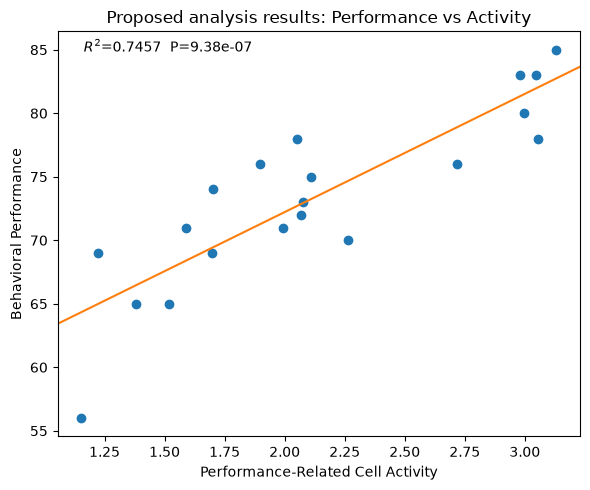

In [5]:
def annotate_corr(ax, PRCA, Perf, title):
    #: plot the data points (Perf vs PRCS)
    ax.plot(PRCA, Perf, "o", color="tab:blue", markerfacecolor="tab:blue")
    # run the regression
    fit = stats.linregress(PRCA, Perf)
    x_reg = np.array(ax.get_xlim())
    #: get and plot the regression's y coordinates from the fit result's slope and intercept
    ax.plot(x_reg, fit.slope * x_reg + fit.intercept, "-", color="tab:orange")
    # polish the plot
    ax.set_xlim(x_reg)
    ax.set_xlabel("Performance-Related Cell Activity")
    ax.set_ylabel("Behavioral Performance")
    ax.set_title(title)
    Rsquared = fit.rvalue ** 2
    xlims, ylims = ax.get_xlim(), ax.get_ylim()

    xpos = xlims[0] + 0.05 * (xlims[1] - xlims[0])
    ypos = ylims[1] - 0.05 * (ylims[1] - ylims[0])
    ax.text(xpos, ypos, f"$R^2$={Rsquared:.4f}  P={fit.pvalue:.2e}")


fig, ax = plt.subplots(figsize=(6, 5))
#: try your function here, with an informative title...
annotate_corr(ax, PRCA, Perf, "Proposed analysis results: Performance vs Activity")
plt.tight_layout()
plt.show()



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; color: #000000;">

## What to think about

The ground truth here is that cell activity is completely unrelated to behavioral
performance — 

- Did anyone get a convincing-looking positive trend with a high
$R^2$ and a small $p$ value?
- Would you have believed this result?
- How do these selected "Performance-related cells" compare to the rest of the recorded cells?

</div>


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">
<p><b>Task 1.4:</b>  Think and discuss with your neighbor, then fill in the code to plot <i>all</i> p and r-values
</div>

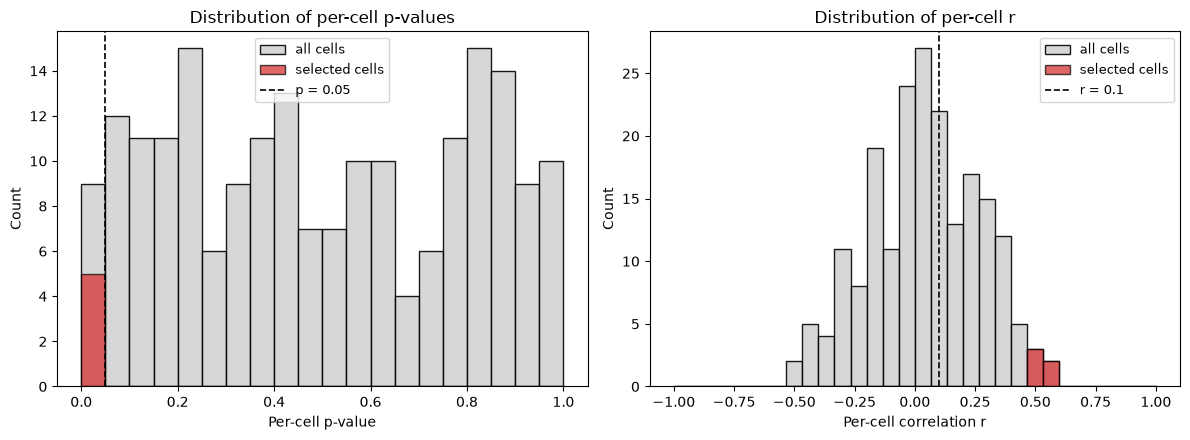

In [6]:
# Plot distributions of p-values and r for all cells, with selected cells highlighted.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# p-values
bins_p = np.linspace(0, 1, 21)
axes[0].hist(p, bins=bins_p, color="lightgray", edgecolor="k", alpha=0.9, label="all cells")
if SelectedCells.size > 0:
    axes[0].hist(p[SelectedCells], bins=bins_p, color="tab:red", edgecolor="k", alpha=0.7,
                 label="selected cells")
axes[0].axvline(0.05, color="k", linestyle="--", linewidth=1.2, label="p = 0.05")
axes[0].set_xlabel("Per-cell p-value")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of per-cell p-values")
axes[0].legend(fontsize=9)

# r-values
#: do the same for r using axes[1]
bins_r = np.linspace(-1, 1, 31)
axes[1].hist(r, bins=bins_r, color="lightgray", edgecolor="k", alpha=0.9, label="all cells")
if SelectedCells.size > 0:
    axes[1].hist(r[SelectedCells], bins=bins_r, color="tab:red", edgecolor="k", alpha=0.7,
                 label="selected cells")
axes[1].axvline(0.1, color="k", linestyle="--", linewidth=1.2, label="r = 0.1")
axes[1].set_xlabel("Per-cell correlation r")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of per-cell r")
axes[1].legend(fontsize=9)

#
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; color: #000000;">

## Is this result consistent?

A single run either clears the $p < 0.05$ bar or it doesn't — it could be due to a quirk of our analysis. 
To address this, we repeat the simulation many times (fresh cell activity each run, the same fixed `Perf`) and
collect the final $p$-value and $R^2$ from every run.

</div>


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Task 1.5**: Fill in the missing analysis pieces and run in a loop
</div>

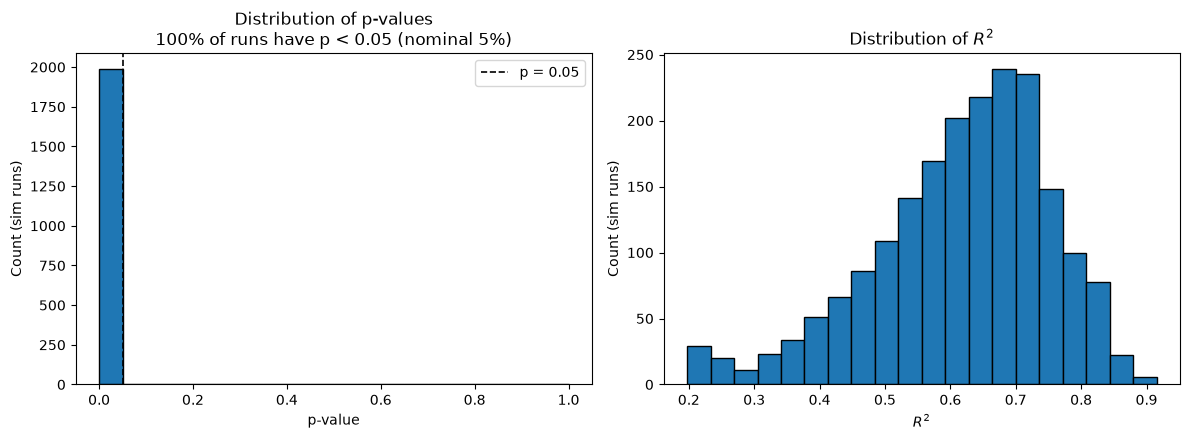

Results over 2000 runs:
  fraction with p < 0.05 : 100.0%  (nominal 5%)
  median R^2             : 0.639


In [7]:
# Repeat the proposed analysis many times and collect p and R^2.
N_sim = 2000
pvals_sim = []
r2_sim = []
for _ in range(N_sim):
    DA_n = sd_dff * rng.standard_normal((Ngroups, Ncells))
    res = stats.pearsonr(DA_n, Perf[:, np.newaxis], axis=0)
    sel = np.where((res.statistic > 0.1) & (res.pvalue < 0.05))[0]
    if sel.size == 0:
        continue
    #: run pearsonr or linregress on the mean of the selected cells' activity vs Perf
    rr, pp = stats.pearsonr(DA_n[:, sel].mean(axis=1), Perf)
    # append the results to the simulation lists
    pvals_sim.append(pp)
    r2_sim.append(rr ** 2)

pvals_sim = np.array(pvals_sim)
r2_sim = np.array(r2_sim)
frac_sig = np.mean(pvals_sim < 0.05)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(pvals_sim, bins=np.linspace(0, 1, 21), color="tab:blue", edgecolor="k")
axes[0].axvline(0.05, color="k", linestyle="--", linewidth=1.2, label="p = 0.05")
axes[0].set_xlabel("p-value")
axes[0].set_ylabel("Count (sim runs)")
axes[0].set_title(f"Distribution of p-values\n"
                  f"{frac_sig:.0%} of runs have p < 0.05 (nominal 5%)")
axes[0].legend()

axes[1].hist(r2_sim, bins=20, color="tab:blue", edgecolor="k")
axes[1].set_xlabel("$R^2$")
axes[1].set_ylabel("Count (sim runs)")
axes[1].set_title("Distribution of $R^2$")

plt.tight_layout()
plt.show()

print(f"Results over {N_sim} runs:")
print(f"  fraction with p < 0.05 : {frac_sig:.1%}  (nominal 5%)")
print(f"  median R^2             : {np.median(r2_sim):.3f}")
